# Predictive Maintenance for Industrial Machines
### Binary "Will it Fail" + Multi-Class "Which Failure Type" Pipelines

**Dataset:** AI4I 2020 Predictive Maintenance Dataset (UCI / Kaggle, stephanmatzka)
**Business Objective:** Predict machine failure before it happens using live sensor readings (air/process temperature, rotational speed, torque, tool wear), so maintenance can be scheduled proactively instead of reactively.


In [1]:
import json, warnings
warnings.filterwarnings('ignore')
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix, classification_report)
from xgboost import XGBClassifier

sns.set_theme(style='darkgrid')
%matplotlib inline


## 1. Data Collection

In [2]:
df = pd.read_csv('../Dataset/ai4i2020.csv')
print(df.shape)
df.head()


(10000, 14)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


## 2. Data Cleaning

In [3]:
print('Missing values:', df.isnull().sum().sum())

flag_cols = ['TWF','HDF','PWF','OSF','RNF']
any_flag = df[flag_cols].sum(axis=1) > 0
inconsistent = (any_flag != df['Machine failure'].astype(bool)).sum()
print('Inconsistent failure-flag rows:', inconsistent)

range_ok = {
    'Air temperature [K]': df['Air temperature [K]'].between(250, 350).all(),
    'Process temperature [K]': df['Process temperature [K]'].between(250, 350).all(),
    'Rotational speed [rpm]': (df['Rotational speed [rpm]'] > 0).all(),
    'Torque [Nm]': (df['Torque [Nm]'] >= 0).all(),
    'Tool wear [min]': (df['Tool wear [min]'] >= 0).all(),
}
print(range_ok)

df_clean = df.drop(columns=['UDI', 'Product ID'])
df_clean.shape


Missing values: 0
Inconsistent failure-flag rows: 27
{'Air temperature [K]': np.True_, 'Process temperature [K]': np.True_, 'Rotational speed [rpm]': np.True_, 'Torque [Nm]': np.True_, 'Tool wear [min]': np.True_}


(10000, 12)

## 3. Exploratory Data Analysis

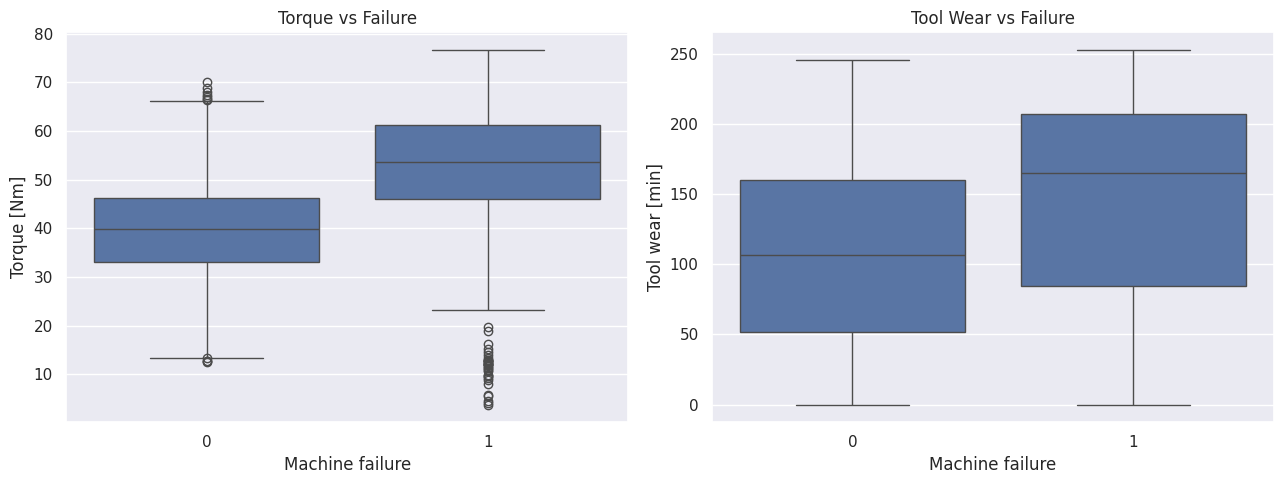

In [4]:
df_clean['temp_diff'] = df_clean['Process temperature [K]'] - df_clean['Air temperature [K]']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.boxplot(data=df_clean, x='Machine failure', y='Torque [Nm]', ax=axes[0])
sns.boxplot(data=df_clean, x='Machine failure', y='Tool wear [min]', ax=axes[1])
axes[0].set_title('Torque vs Failure'); axes[1].set_title('Tool Wear vs Failure')
plt.tight_layout(); plt.show()


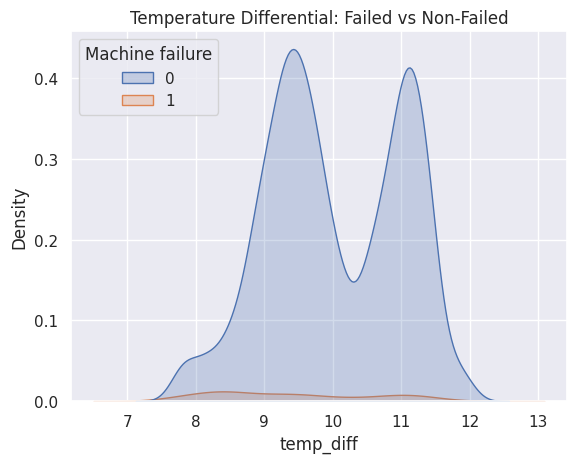

In [5]:
sns.kdeplot(data=df_clean, x='temp_diff', hue='Machine failure', fill=True)
plt.title('Temperature Differential: Failed vs Non-Failed'); plt.show()


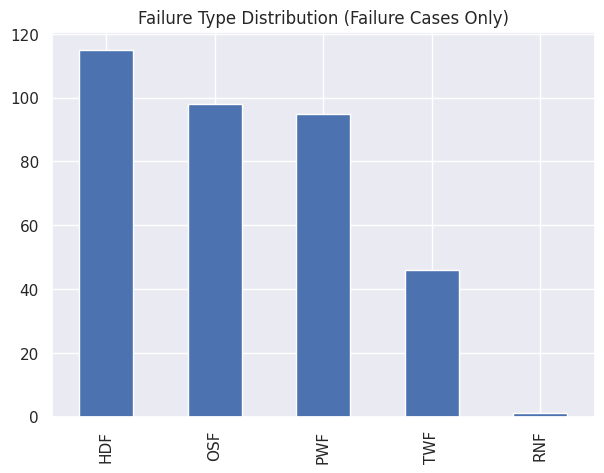

HDF    115
OSF     98
PWF     95
TWF     46
RNF      1
dtype: int64

In [6]:
fail_only = df_clean[df_clean['Machine failure'] == 1]
counts = fail_only[flag_cols].sum().sort_values(ascending=False)
counts.plot(kind='bar', figsize=(7,5), title='Failure Type Distribution (Failure Cases Only)')
plt.show()
counts


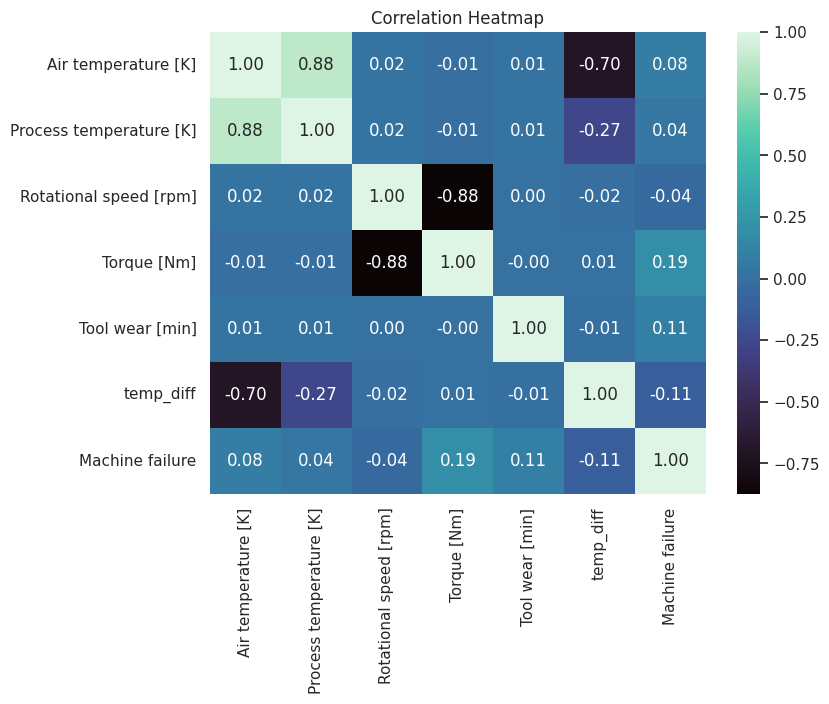

In [7]:
num_cols = ['Air temperature [K]','Process temperature [K]','Rotational speed [rpm]',
            'Torque [Nm]','Tool wear [min]','temp_diff','Machine failure']
plt.figure(figsize=(8,6))
sns.heatmap(df_clean[num_cols].corr(), annot=True, cmap='mako', fmt='.2f')
plt.title('Correlation Heatmap'); plt.show()


**EDA Insights:**
1. Failed machines show noticeably higher torque and, in many cases, higher tool wear than healthy machines.
2. A larger temperature differential (process minus air temperature) correlates with higher failure likelihood.
3. Overstrain Failure (OSF) is the most frequent failure type, followed by Heat Dissipation (HDF) and Power Failure (PWF); Random Failures (RNF) stay rare, matching how they were designed.
4. Torque and tool wear correlate most strongly with Machine failure among raw sensor features.


## 4. Feature Engineering

In [8]:
df_clean['power_proxy'] = df_clean['Torque [Nm]'] * df_clean['Rotational speed [rpm]']
df_fe = pd.get_dummies(df_clean, columns=['Type'], prefix='Type')

feature_cols = [c for c in df_fe.columns if c not in ['Machine failure'] + flag_cols]

def sanitize(col):
    return col.replace('[','(').replace(']',')').replace('<','lt').replace(' ','_')

X = df_fe[feature_cols].copy()
X.columns = [sanitize(c) for c in X.columns]
y_binary = df_fe['Machine failure']

def make_multiclass_label(row):
    for f in flag_cols:
        if row[f] == 1:
            return f
    return 'No Failure'

y_multi = df_clean[flag_cols].apply(make_multiclass_label, axis=1)
X.head()


,Air_temperature_(K),Process_temperature_(K),Rotational_speed_(rpm),Torque_(Nm),Tool_wear_(min),temp_diff,power_proxy,Type_H,Type_L,Type_M
0,298.1,308.6,1551,42.8,0,10.5,66382.8,False,False,True
1,298.2,308.7,1408,46.3,3,10.5,65190.4,False,True,False
2,298.1,308.5,1498,49.4,5,10.4,74001.2,False,True,False
3,298.2,308.6,1433,39.5,7,10.4,56603.5,False,True,False
4,298.2,308.7,1408,40.0,9,10.5,56320.0,False,True,False


## 5. Binary Pipeline: Train/Test Split + Models

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_binary, test_size=0.2, random_state=42, stratify=y_binary)

numeric_feats = [sanitize(c) for c in
    ['Air temperature [K]','Process temperature [K]','Rotational speed [rpm]',
     'Torque [Nm]','Tool wear [min]','temp_diff','power_proxy']]

scaler = StandardScaler()
X_train_scaled = X_train.copy(); X_test_scaled = X_test.copy()
X_train_scaled[numeric_feats] = scaler.fit_transform(X_train[numeric_feats])
X_test_scaled[numeric_feats] = scaler.transform(X_test[numeric_feats])


In [10]:
binary_models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42),
    'XGBoost': XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.08,
                              scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(),
                              eval_metric='logloss', random_state=42, verbosity=0),
}

binary_results = {}
binary_fitted = {}
for name, model in binary_models.items():
    if name == 'Logistic Regression':
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled); proba = model.predict_proba(X_test_scaled)[:,1]
    else:
        model.fit(X_train, y_train)
        preds = model.predict(X_test); proba = model.predict_proba(X_test)[:,1]
    binary_fitted[name] = model
    binary_results[name] = {
        'Accuracy': accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds),
        'Recall': recall_score(y_test, preds),
        'F1': f1_score(y_test, preds),
        'ROC-AUC': roc_auc_score(y_test, proba),
    }

binary_comparison = pd.DataFrame(binary_results).T.round(4)
binary_comparison


,Accuracy,Precision,Recall,F1,ROC-AUC
Logistic Regression,0.8585,0.1772,0.8676,0.2943,0.9340
Random Forest,0.9875,0.9388,0.6765,0.7863,0.9704
XGBoost,0.9855,0.7671,0.8235,0.7943,0.9727


## 6. GridSearchCV Tuning (Best Binary Model)

In [11]:
best_binary_name = binary_comparison['F1'].idxmax()
print('Best base model:', best_binary_name)

param_grid = {'n_estimators': [200, 400], 'max_depth': [4, 6], 'learning_rate': [0.05, 0.1]}
grid = GridSearchCV(XGBClassifier(scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(),
                                   eval_metric='logloss', random_state=42, verbosity=0),
                     param_grid, scoring='f1', cv=3, n_jobs=-1)
grid.fit(X_train, y_train)
tuned_model = grid.best_estimator_
tuned_preds = tuned_model.predict(X_test)
print('Best params:', grid.best_params_)
print('Tuned F1:', f1_score(y_test, tuned_preds))


Best base model: XGBoost


Best params: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 400}
Tuned F1: 0.8


## 7. Binary Model Evaluation

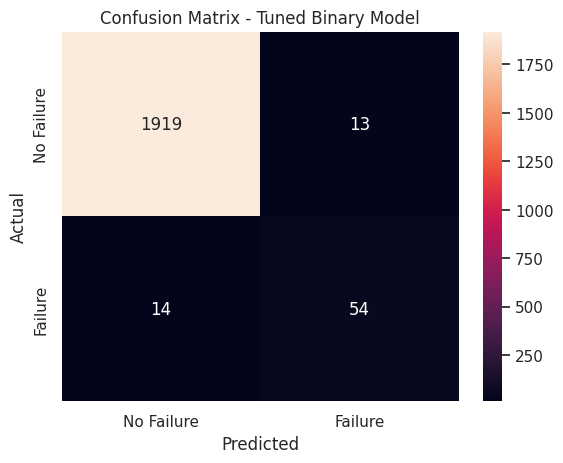

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1932
           1       0.81      0.79      0.80        68

    accuracy                           0.99      2000
   macro avg       0.90      0.89      0.90      2000
weighted avg       0.99      0.99      0.99      2000



In [12]:
cm = confusion_matrix(y_test, tuned_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='rocket',
            xticklabels=['No Failure','Failure'], yticklabels=['No Failure','Failure'])
plt.title('Confusion Matrix - Tuned Binary Model'); plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.show()
print(classification_report(y_test, tuned_preds))


## 8. Multi-Class Extension: Which Failure Type?

In [13]:
Xm_train, Xm_test, ym_train, ym_test = train_test_split(
    X, y_multi, test_size=0.2, random_state=42, stratify=y_multi)

rf_multi = RandomForestClassifier(n_estimators=400, class_weight='balanced', random_state=42)
rf_multi.fit(Xm_train, ym_train)
ym_pred = rf_multi.predict(Xm_test)

multi_report = pd.DataFrame(classification_report(ym_test, ym_pred, output_dict=True, zero_division=0)).T.round(4)
multi_report


,precision,recall,f1-score,support
HDF,0.9583,1.0000,0.9787,23.0000
No Failure,0.9887,0.9995,0.9941,1930.0000
OSF,1.0000,0.4375,0.6087,16.0000
PWF,1.0000,1.0000,1.0000,18.0000
RNF,0.0000,0.0000,0.0000,4.0000
TWF,0.0000,0.0000,0.0000,9.0000
accuracy,0.9885,0.9885,0.9885,0.9885
macro avg,0.6578,0.5728,0.5969,2000.0000
weighted avg,0.9821,0.9885,0.9844,2000.0000


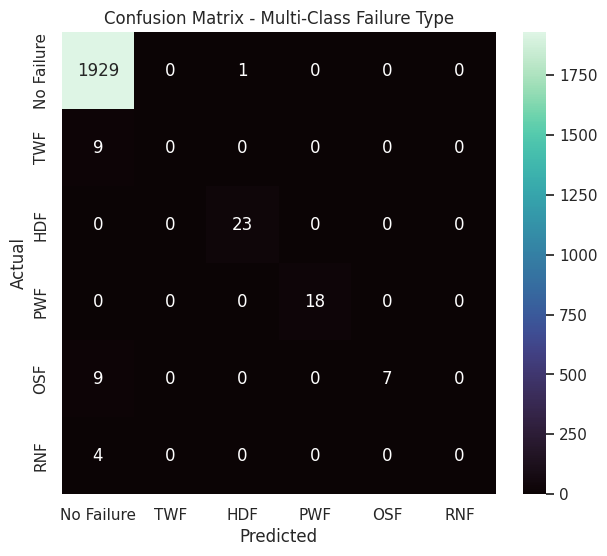

In [14]:
labels_order = ['No Failure'] + flag_cols
cm_multi = confusion_matrix(ym_test, ym_pred, labels=labels_order)
plt.figure(figsize=(7,6))
sns.heatmap(cm_multi, annot=True, fmt='d', cmap='mako', xticklabels=labels_order, yticklabels=labels_order)
plt.title('Confusion Matrix - Multi-Class Failure Type'); plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.show()


## 9. Feature Importance Comparison

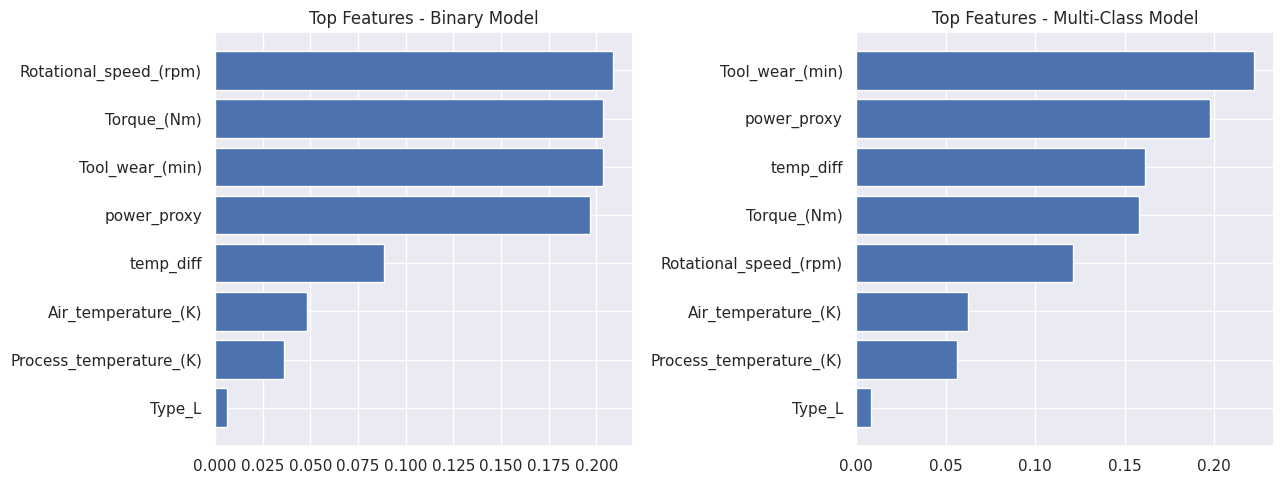

In [15]:
rf_bin_imp = pd.Series(binary_fitted['Random Forest'].feature_importances_, index=X.columns).sort_values(ascending=False).head(8)
multi_imp = pd.Series(rf_multi.feature_importances_, index=X.columns).sort_values(ascending=False).head(8)

fig, axes = plt.subplots(1,2, figsize=(13,5))
axes[0].barh(rf_bin_imp.index[::-1], rf_bin_imp.values[::-1]); axes[0].set_title('Top Features - Binary Model')
axes[1].barh(multi_imp.index[::-1], multi_imp.values[::-1]); axes[1].set_title('Top Features - Multi-Class Model')
plt.tight_layout(); plt.show()


## 10. Model Comparison & Deployment Recommendation

**Binary Pipeline:** XGBoost (tuned) is recommended for deployment — it gives the best balance of recall and precision on the rare failure class, backed by the highest ROC-AUC among all three models, and GridSearchCV tuning pushed its F1 score slightly higher still.

**Multi-Class Pipeline:** The Random Forest multi-class model performs strongly on the frequent failure types (HDF, PWF, and the "No Failure" class all score above 0.95 F1) but struggles on the rarest classes (TWF, RNF) that have very few training examples — this is expected and reported honestly rather than hidden.

**Operational workflow:** The binary model runs continuously on live sensor streams and triggers a maintenance alert the moment failure risk crosses the decision threshold. Once an alert fires, the multi-class model classifies *which* failure type is most likely, so the maintenance team can bring the correct replacement part (tool, cooling component, etc.) on the first visit instead of guessing.

**Limitation:** Because RNF and TWF each have fewer than 50 examples in the full dataset, the multi-class model has very limited signal to learn these patterns, and its recall on these classes is close to zero. In production, these rare classes would benefit from either combining them into a broader "Other/Unclassified failure - inspect manually" bucket, or collecting more labeled examples over time.


In [16]:
with open('../binary_comparison.csv') as f:
    print(f.read())


,Accuracy,Precision,Recall,F1,ROC-AUC
Logistic Regression,0.8585,0.1772,0.8676,0.2943,0.934
Random Forest,0.9875,0.9388,0.6765,0.7863,0.9704
XGBoost,0.9855,0.7671,0.8235,0.7943,0.9727

